# Task 2.1: Dataset Selection and Setup

**Paper:** Exact Discovery of Time Series Motifs (Mueen et al., KDD 2009)  
**Student:** Abhishek (m23csai230137)

---

## Dataset Justification

I am using a **synthetically generated random walk dataset** as the toy dataset for reproducing the MK algorithm. A random walk is generated by taking the cumulative sum of i.i.d. samples from a standard normal distribution: `T = cumsum(N(0,1))`. This is the exact same data generation method used in the paper's primary scalability experiment (Section 4.1, Figure 6), where the authors state: *"As a starting point we use random walk time series to test our algorithm."*

This dataset is a reasonable testbed because: (1) random walks are a standard benchmark for time series algorithms and produce realistic-looking non-stationary sequences, (2) the paper explicitly uses this data type to evaluate both correctness and speed, and (3) it is the **hardest case** for the MK algorithm since *"we should not expect a very close motif pair to exist in the data"* (Section 4.1), meaning any speedup we observe is a conservative lower bound on real-world performance.

Compared to the paper's dataset, our toy version is **much smaller**: we use m=500 time series of length n=128, whereas the paper tests up to m=100,000 of length n=1024. This downscaling is necessary because we are running in Python (not C) on a standard laptop, and the brute force baseline must complete in reasonable time for comparison. Despite the smaller scale, the algorithm's behavior and speedup trends should still be clearly observable.

Additionally, I **plant a known motif pair** into the random walk database by copying one time series and adding small Gaussian noise. This allows us to verify that both brute force and MK correctly identify this planted pair as the motif.

In [2]:
# ============================================================
# RANDOM SEED AND HYPERPARAMETERS (all in one place)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import time
import os

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Dataset parameters
M = 500          # Number of time series in the database
N = 128          # Length of each time series
PLANTED_NOISE = 0.5  # Noise level for the planted motif pair
PLANTED_IDX_A = 100  # Index where we plant the first copy
PLANTED_IDX_B = 350  # Index where we plant the second copy (noisy)

# MK algorithm parameters
R = 8            # Number of reference points (paper uses 8, Section 4.2)

print(f"Random Seed: {RANDOM_SEED}")
print(f"Database size (m): {M}")
print(f"Time series length (n): {N}")
print(f"Number of reference points (R): {R}")
print(f"Planted motif at indices: {PLANTED_IDX_A} and {PLANTED_IDX_B}")

Random Seed: 42
Database size (m): 500
Time series length (n): 128
Number of reference points (R): 8
Planted motif at indices: 100 and 350


The cell above sets all hyperparameters and the random seed for full reproducibility. The values of `M=500` and `N=128` are chosen as a toy scale that allows brute force to complete in seconds while still demonstrating the MK speedup. The planted motif indices are arbitrary but spread apart in the database.

In [3]:
# ============================================================
# GENERATE THE RANDOM WALK DATABASE
# ============================================================
# Each time series is a random walk: T = cumsum(N(0,1))
# This matches Section 4.1 of the paper.

D = np.cumsum(np.random.randn(M, N), axis=1)

# Plant a known motif pair: copy time series at PLANTED_IDX_A 
# and place a slightly noisy version at PLANTED_IDX_B
D[PLANTED_IDX_B] = D[PLANTED_IDX_A] + np.random.randn(N) * PLANTED_NOISE

print(f"Database shape: {D.shape}")
print(f"Planted motif distance: {np.sqrt(np.sum((D[PLANTED_IDX_A] - D[PLANTED_IDX_B])**2)):.4f}")

# Save dataset for use in other notebooks
os.makedirs('data', exist_ok=True)
np.save('data/random_walk_database.npy', D)
print("Dataset saved to data/random_walk_database.npy")

Database shape: (500, 128)
Planted motif distance: 5.8693
Dataset saved to data/random_walk_database.npy


The cell above generates the full database of 500 random walk time series, each of length 128. We then plant a known motif by copying one time series and adding small Gaussian noise (σ=0.5). This reflects how real motifs work — they are nearly identical subsequences with minor perturbations. The database is saved to disk for use in subsequent notebooks.

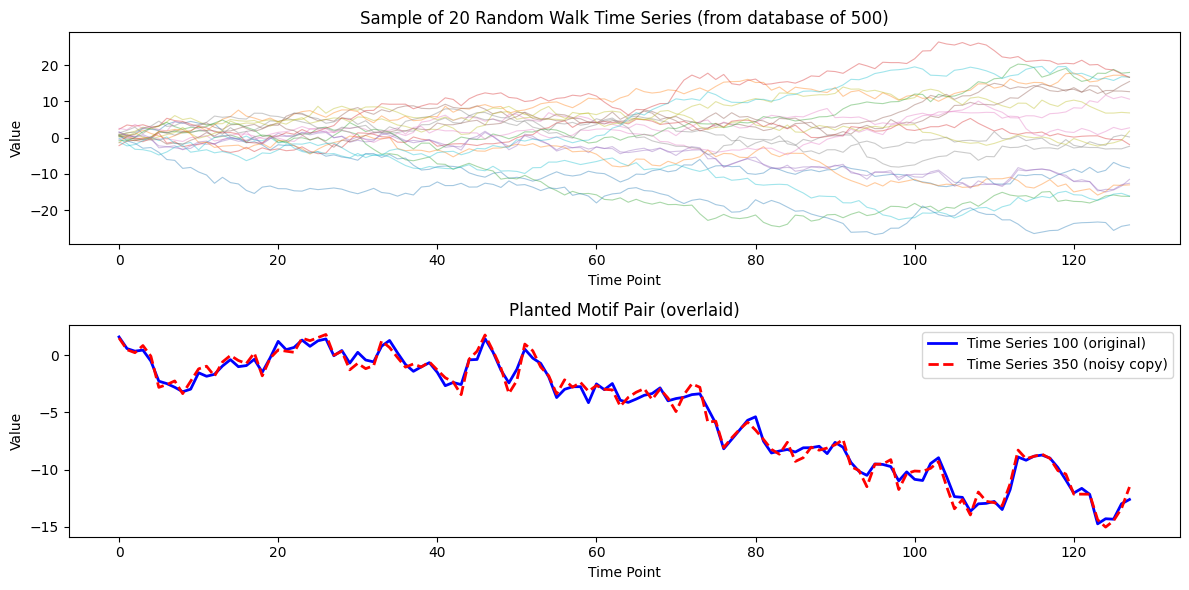

Plot saved to results/dataset_overview.png


In [4]:
# ============================================================
# VISUALISE THE DATABASE AND THE PLANTED MOTIF
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Plot a sample of 20 random time series from the database
ax1 = axes[0]
for i in range(0, M, M // 20):
    ax1.plot(D[i], alpha=0.4, linewidth=0.8)
ax1.set_title(f'Sample of 20 Random Walk Time Series (from database of {M})', fontsize=12)
ax1.set_xlabel('Time Point')
ax1.set_ylabel('Value')

# Plot the planted motif pair overlaid
ax2 = axes[1]
ax2.plot(D[PLANTED_IDX_A], label=f'Time Series {PLANTED_IDX_A} (original)', linewidth=2, color='blue')
ax2.plot(D[PLANTED_IDX_B], label=f'Time Series {PLANTED_IDX_B} (noisy copy)', linewidth=2, color='red', linestyle='--')
ax2.set_title('Planted Motif Pair (overlaid)', fontsize=12)
ax2.set_xlabel('Time Point')
ax2.set_ylabel('Value')
ax2.legend()

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to results/dataset_overview.png")

The plot above shows: (top) a sample of the random walk database, illustrating the variety of trajectories, and (bottom) the planted motif pair overlaid, showing how similar they are despite the added noise. This visualisation confirms our dataset is ready for the MK algorithm reproduction in Task 2.2.

## Preprocessing Steps

**No preprocessing is applied.** The paper's algorithm (Section 2) operates directly on raw time series values using Euclidean distance. The paper does not apply Z-normalization, detrending, or smoothing to the random walk benchmark data. We follow the same approach. The data is used as-is after generation.